## Loading Data and preprocessing

In [12]:
import gzip
import json

def load_json_gz(path, max_samples=1000):  # small sample first
    data = []
    
    with gzip.open(path, 'rt', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= max_samples:
                break
                
            review = json.loads(line)
            
            if 'reviewText' in review and 'overall' in review:
                data.append({
                    'text': review['reviewText'],
                    'rating': review['overall']
                })
    
    return data

sample_data = load_json_gz('Dataset/electronics.json.gz')
print(len(sample_data))
print(sample_data[0])

1000
{'text': 'We got this GPS for my husband who is an (OTR) over the road trucker.  Very Impressed with the shipping time, it arrived a few days earlier than expected...  within a week of use however it started freezing up... could of just been a glitch in that unit.  Worked great when it worked!  Will work great for the normal person as well but does have the "trucker" option. (the big truck routes - tells you when a scale is coming up ect...)  Love the bigger screen, the ease of use, the ease of putting addresses into memory.  Nothing really bad to say about the unit with the exception of it freezing which is probably one in a million and that\'s just my luck.  I contacted the seller and within minutes of my email I received a email back with instructions for an exchange! VERY impressed all the way around!', 'rating': 5.0}


In [13]:
electronics = load_json_gz('Dataset/electronics.json.gz', 12000)
home = load_json_gz('Dataset/home.json.gz', 12000)
sports = load_json_gz('Dataset/sports.json.gz', 12000)

dataset = electronics + home + sports

print("Total:", len(dataset))

Total: 36000


In [14]:
import pandas as pd

df = pd.DataFrame(dataset)
df = df.dropna()

print(df.head())

                                                text  rating
0  We got this GPS for my husband who is an (OTR)...     5.0
1  I'm a professional OTR truck driver, and I bou...     1.0
2  Well, what can I say.  I've had this unit in m...     3.0
3  Not going to write a long review, even thought...     2.0
4  I've had mine for a year and here's what we go...     1.0


In [107]:
print(df.head(1))

                                                text  rating  sentiment
0  We got this GPS for my husband who is an (OTR)...     5.0          2


In [15]:
def map_sentiment(rating):
    if rating <= 2:
        return 0
    elif rating == 3:
        return 1
    else:
        return 2

df['sentiment'] = df['rating'].apply(map_sentiment)

In [16]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(len(train_df), len(val_df), len(test_df))

25200 5400 5400


In [17]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    # Keeps alphanumeric characters
    text = re.sub(r'[^a-z0-9\s]', '', text) 
    return text

In [18]:
train_df['clean_text'] = train_df['text'].apply(clean_text)
val_df['clean_text'] = val_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

In [19]:
print(clean_text(train_df['text'].iloc[0]))

awesome addition to my rebel t3i takes incredible pictures from pretty far away i am still getting used to the camera and all the settings but even on auto mode the lens works very well i am by no means a photographer but for my needs it is amazing the lens easily attaches to the camera and comes with two caps for both sides of the lens to keep the dust out and protected when not in use


In [20]:
def tokenize(text):
    return text.split()

print(tokenize(clean_text(train_df['text'].iloc[0])))

['awesome', 'addition', 'to', 'my', 'rebel', 't3i', 'takes', 'incredible', 'pictures', 'from', 'pretty', 'far', 'away', 'i', 'am', 'still', 'getting', 'used', 'to', 'the', 'camera', 'and', 'all', 'the', 'settings', 'but', 'even', 'on', 'auto', 'mode', 'the', 'lens', 'works', 'very', 'well', 'i', 'am', 'by', 'no', 'means', 'a', 'photographer', 'but', 'for', 'my', 'needs', 'it', 'is', 'amazing', 'the', 'lens', 'easily', 'attaches', 'to', 'the', 'camera', 'and', 'comes', 'with', 'two', 'caps', 'for', 'both', 'sides', 'of', 'the', 'lens', 'to', 'keep', 'the', 'dust', 'out', 'and', 'protected', 'when', 'not', 'in', 'use']


In [21]:
from collections import Counter

def build_vocab(texts, min_freq=2):
    counter = Counter()
    
    for text in texts:
        tokens = tokenize(clean_text(text))
        counter.update(tokens)
    
    vocab = {'<PAD>': 0, '<UNK>': 1}
    
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    
    return vocab

vocab = build_vocab(train_df['text'])
print("Vocab size:", len(vocab))

Vocab size: 24630


In [22]:
def encode(text, vocab, max_len=100):
    tokens = tokenize(clean_text(text))
    
    encoded = [vocab.get(token, vocab['<UNK>']) for token in tokens]
    
    if len(encoded) < max_len:
        encoded += [vocab['<PAD>']] * (max_len - len(encoded))
    else:
        encoded = encoded[:max_len]
    
    return encoded

In [ ]:
MAX_LEN = 100

train_df['encoded'] = train_df['text'].apply(lambda x: encode(x, vocab, MAX_LEN))
val_df['encoded'] = val_df['text'].apply(lambda x: encode(x, vocab, MAX_LEN))
test_df['encoded'] = test_df['text'].apply(lambda x: encode(x, vocab, MAX_LEN))

In [24]:
def length_feature(text):
    length = len(text.split())
    
    if length <= 50:
        return 0
    elif length <= 150:
        return 1
    else:
        return 2

train_df['length_label'] = train_df['text'].apply(length_feature)
val_df['length_label'] = val_df['text'].apply(length_feature)
test_df['length_label'] = test_df['text'].apply(length_feature)

## Part A

PyTorch Dataset

In [25]:
import torch
from torch.utils.data import Dataset

class ReviewDataset(Dataset):
    def __init__(self, df):
        self.X = df['encoded'].tolist()
        self.y_sent = df['sentiment'].tolist()
        self.y_len = df['length_label'].tolist()
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx], dtype=torch.long),
            torch.tensor(self.y_sent[idx], dtype=torch.long),
            torch.tensor(self.y_len[idx], dtype=torch.long)
        )

Positional Encoding

In [26]:
import math
import torch.nn as nn

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        
        pe = torch.zeros(max_len, d_model)
        
        for pos in range(max_len):
            for i in range(0, d_model, 2):
                pe[pos, i] = math.sin(pos / (10000 ** ((2*i)/d_model)))
                if i+1 < d_model:
                    pe[pos, i+1] = math.cos(pos / (10000 ** ((2*i)/d_model)))
        
        self.pe = pe.unsqueeze(0)  # (1, max_len, d_model)
    
    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

SELF-ATTENTION

In [27]:
class SelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        
        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
    
    def forward(self, x):
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)
        
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(Q.size(-1))
        attention = torch.softmax(scores, dim=-1)
        
        out = torch.matmul(attention, V)
        return out

MULTI-HEAD ATTENTION

In [28]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        
        self.heads = nn.ModuleList(
            [SelfAttention(d_model) for _ in range(num_heads)]
        )
        
        self.fc = nn.Linear(d_model * num_heads, d_model)
    
    def forward(self, x):
        head_outputs = [head(x) for head in self.heads]
        concat = torch.cat(head_outputs, dim=-1)
        return self.fc(concat)

FEED FORWARD

In [29]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
    
    def forward(self, x):
        return self.net(x)

ENCODER BLOCK

In [30]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        
        self.attn = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        
        self.ff = FeedForward(d_model, d_ff)
        self.norm2 = nn.LayerNorm(d_model)
    
    def forward(self, x):
        attn_out = self.attn(x)
        x = self.norm1(x + attn_out)
        
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)
        
        return x

ENCODER MODEL

In [31]:
class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model=128, num_heads=4, d_ff=256, num_layers=2):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        
        self.layers = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_ff)
            for _ in range(num_layers)
        ])
        
        # Shared representation → 3 outputs
        self.sentiment_head = nn.Linear(d_model, 3)
        self.length_head = nn.Linear(d_model, 3)
    
    def forward(self, x):
        x = self.embedding(x)
        x = self.pos_encoding(x)
        
        for layer in self.layers:
            x = layer(x)
        
        # Pooling (mean)
        representation = x.mean(dim=1)
        
        sentiment = self.sentiment_head(representation)
        length = self.length_head(representation)
        
        return sentiment, length, representation

TRAINING SETUP

In [32]:
from torch.utils.data import DataLoader

train_loader = DataLoader(ReviewDataset(train_df), batch_size=32, shuffle=True)
val_loader = DataLoader(ReviewDataset(val_df), batch_size=32)

TRAINING LOOP (COMBINED LOSS)

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TransformerEncoder(vocab_size=len(vocab)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Training

In [34]:
train_losses = []

for epoch in range(5):
    model.train()
    total_loss = 0
    
    for X, y_sent, y_len in train_loader:
        X, y_sent, y_len = X.to(device), y_sent.to(device), y_len.to(device)
        
        optimizer.zero_grad()
        
        pred_sent, pred_len, _ = model(X)
        
        loss1 = criterion(pred_sent, y_sent)
        loss2 = criterion(pred_len, y_len)
        
        loss = loss1 + loss2   # combined loss
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 0.7604
Epoch 2, Loss: 0.7403
Epoch 3, Loss: 0.7637
Epoch 4, Loss: 1.3959
Epoch 5, Loss: 0.7877


Evaluation

In [35]:
from sklearn.metrics import accuracy_score

model.eval()

y_true_sent, y_pred_sent = [], []
y_true_len, y_pred_len = [], []

with torch.no_grad():
    for X, y_sent, y_len in val_loader:
        X = X.to(device)
        
        pred_sent, pred_len, _ = model(X)
        
        y_pred_sent.extend(torch.argmax(pred_sent, dim=1).cpu().numpy())
        y_true_sent.extend(y_sent.numpy())
        
        y_pred_len.extend(torch.argmax(pred_len, dim=1).cpu().numpy())
        y_true_len.extend(y_len.numpy())

print("Sentiment Accuracy:", accuracy_score(y_true_sent, y_pred_sent))
print("Length Accuracy:", accuracy_score(y_true_len, y_pred_len))

Sentiment Accuracy: 0.8557407407407407
Length Accuracy: 0.872037037037037


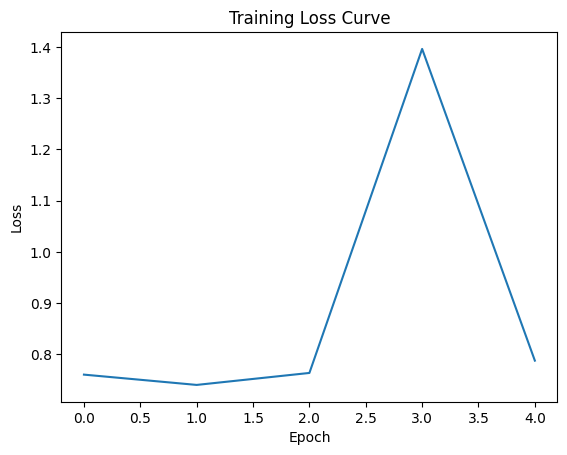

In [38]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

Saving Embeddings

In [37]:
import numpy as np

model.eval()
embeddings = []

with torch.no_grad():
    for X, _, _ in train_loader:
        X = X.to(device)
        _, _, rep = model(X)
        embeddings.append(rep.cpu().numpy())

embeddings = np.vstack(embeddings)

np.save("results/train_embeddings.npy", embeddings)


TASK 1: SENTIMENT CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       394
     Neutral       0.00      0.00      0.00       385
    Positive       0.86      1.00      0.92      4621

    accuracy                           0.86      5400
   macro avg       0.29      0.33      0.31      5400
weighted avg       0.73      0.86      0.79      5400


TASK 2: LENGTH FEATURE CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Short       0.99      1.00      0.99      2418
      Medium       0.99      0.68      0.81      2114
        Long       0.57      0.99      0.72       868

    accuracy                           0.87      5400
   macro avg       0.85      0.89      0.84      5400
weighted avg       0.92      0.87      0.88      5400



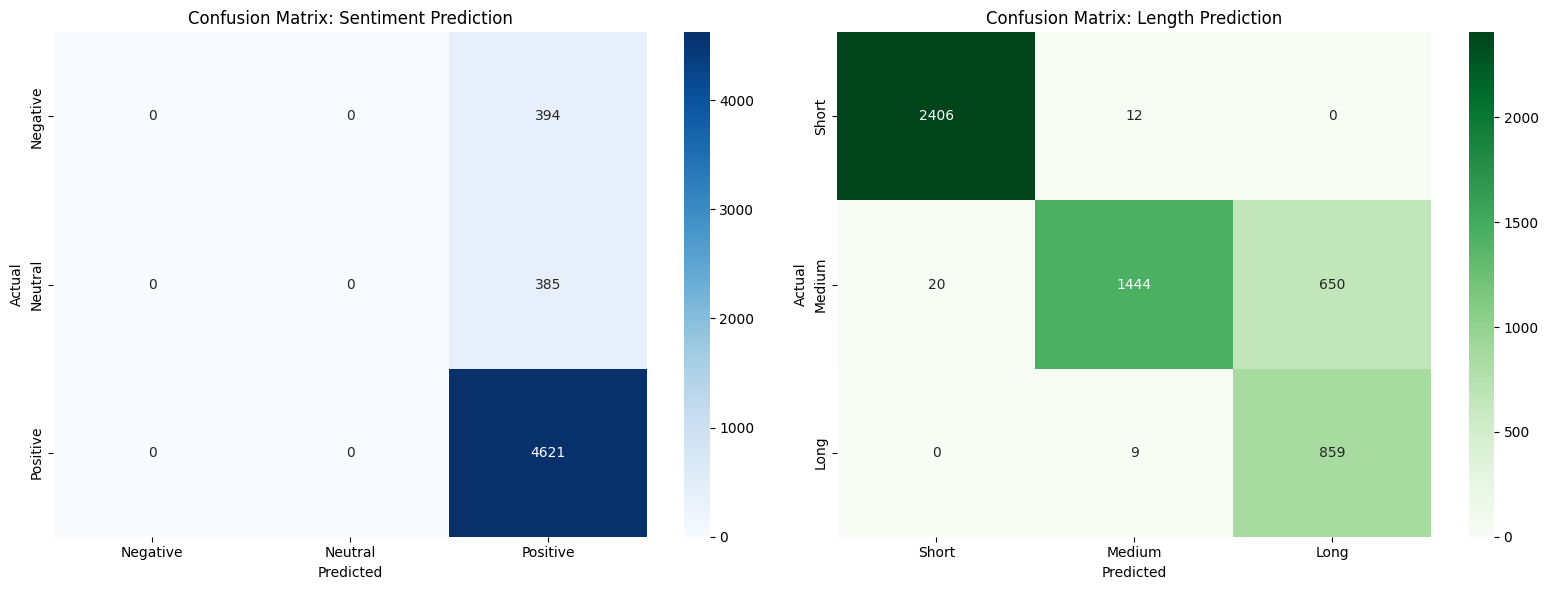

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import numpy as np
import torch
import warnings
warnings.filterwarnings("ignore")

def plot_final_evaluation(model, loader, device):
    model.eval()
    
    # Storage for predictions and actual labels
    sent_preds, sent_true = [], []
    len_preds, len_true = [], []
    
    with torch.no_grad():
        for X, y_sent, y_len in loader:
            X, y_sent, y_len = X.to(device), y_sent.to(device), y_len.to(device)
            
            # Get predictions from both heads
            pred_sent_logits, pred_len_logits, _ = model(X)
            
            sent_preds.extend(torch.argmax(pred_sent_logits, dim=1).cpu().numpy())
            sent_true.extend(y_sent.cpu().numpy())
            
            len_preds.extend(torch.argmax(pred_len_logits, dim=1).cpu().numpy())
            len_true.extend(y_len.cpu().numpy())

    # Define Label Names as per Assignment requirements
    sentiment_labels = ['Negative', 'Neutral', 'Positive']
    length_labels = ['Short', 'Medium', 'Long']

    # --- TASK 1: SENTIMENT ANALYSIS METRICS ---
    print("\n" + "="*30)
    print("TASK 1: SENTIMENT CLASSIFICATION REPORT")
    print("="*30)
    print(classification_report(sent_true, sent_preds, target_names=sentiment_labels))

    # --- TASK 2: LENGTH FEATURE METRICS ---
    print("\n" + "="*30)
    print("TASK 2: LENGTH FEATURE CLASSIFICATION REPORT")
    print("="*30)
    print(classification_report(len_true, len_preds, target_names=length_labels))

    # --- VISUALIZATION: CONFUSION MATRICES ---
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Sentiment Matrix
    cm_sent = confusion_matrix(sent_true, sent_preds)
    sns.heatmap(cm_sent, annot=True, fmt='d', cmap='Blues', 
                xticklabels=sentiment_labels, yticklabels=sentiment_labels, ax=ax[0])
    ax[0].set_title('Confusion Matrix: Sentiment Prediction')
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Actual')

    # Length Matrix
    cm_len = confusion_matrix(len_true, len_preds)
    sns.heatmap(cm_len, annot=True, fmt='d', cmap='Greens', 
                xticklabels=length_labels, yticklabels=length_labels, ax=ax[1])
    ax[1].set_title('Confusion Matrix: Length Prediction')
    ax[1].set_xlabel('Predicted')
    ax[1].set_ylabel('Actual')

    plt.tight_layout()
    plt.show()

# Run the evaluation
plot_final_evaluation(model, val_loader, device)

## Part B

LOAD TRAIN EMBEDDINGS

In [39]:
import numpy as np

train_embeddings = np.load("results/train_embeddings.npy")

print("Embeddings shape:", train_embeddings.shape)

Embeddings shape: (25200, 128)


Alignment checking

In [40]:
len(train_embeddings) == len(train_df)

True

NORMALIZE EMBEDDINGS (for cosine similarity)

In [41]:
def normalize(vectors):
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    return vectors / (norms + 1e-8)

train_embeddings = normalize(train_embeddings)

QUERY CONSTRUCTION

In [42]:
def get_query_embedding(model, text_encoded):
    model.eval()
    
    with torch.no_grad():
        x = torch.tensor(text_encoded).unsqueeze(0).to(device)
        _, _, rep = model(x)
    
    return rep.cpu().numpy()[0]

SIMILARITY SEARCH

In [43]:
def retrieve_top_k(query_vec, train_embeddings, k=5):
    
    query_vec = query_vec / (np.linalg.norm(query_vec) + 1e-8)
    
    # cosine similarity
    scores = np.dot(train_embeddings, query_vec)
    
    top_k_idx = np.argsort(scores)[-k:][::-1]
    
    return top_k_idx, scores[top_k_idx]

FULL RETRIEVAL FUNCTION

In [10]:
def retrieve_reviews(model, test_row, train_df, train_embeddings, k=5):
    
    query_vec = get_query_embedding(model, test_row['encoded'])
    
    indices, scores = retrieve_top_k(query_vec, train_embeddings, k)
    
    retrieved = []
    
    for idx, score in zip(indices, scores):
        retrieved.append({
            "text": train_df.iloc[idx]['text'],
            "sentiment": train_df.iloc[idx]['sentiment'],
            "score": score
        })
    
    return retrieved

TEST RETRIEVAL

In [11]:
sample = test_df.iloc[0]

results = retrieve_reviews(model, sample, train_df, train_embeddings, k=5)

print("QUERY REVIEW:\n", sample['text'])

print("\nTOP RETRIEVED:\n")
for i, r in enumerate(results):
    print(f"[{i+1}] Score: {r['score']:.4f}")
    print(r['text'][:200])
    print()

NameError: name 'test_df' is not defined

SAVE RETRIEVAL RESULTS

In [46]:
import pickle

retrieval_results = []

for i in range(len(test_df)):
    retrieved = retrieve_reviews(model, test_df.iloc[i], train_df, train_embeddings, k=5)
    
    retrieval_results.append(retrieved)

with open("results/retrieved_context.pkl", "wb") as f:
    pickle.dump(retrieval_results, f)

FAST RETRIEVAL

In [47]:
def batch_retrieve(query_matrix, train_embeddings, k=5):
    scores = np.dot(query_matrix, train_embeddings.T)
    
    top_k_idx = np.argsort(scores, axis=1)[:, -k:][:, ::-1]
    
    return top_k_idx

## Part C

Helper to convert labels to text

In [54]:
def sentiment_to_text(label):
    return ["negative", "neutral", "positive"][label]

def length_to_text(label):
    return ["short", "medium", "long"][label]

BUILD INPUT STRING

With Retrieval

In [55]:
def build_input(row, retrieved):
    context = "\n".join([r['text'] for r in retrieved])
    
    text = f"[REVIEW] {row['text']}\n"
    text += f"[SENTIMENT] {sentiment_to_text(row['sentiment'])}\n"
    text += f"[LENGTH] {length_to_text(row['length_label'])}\n"
    text += f"[RETRIEVED]\n{context}\n"
    text += "[EXPLANATION]"
    
    return text

Without Retrival

In [56]:
def build_input_no_retrieval(row):
    text = f"[REVIEW] {row['text']}\n"
    text += f"[SENTIMENT] {sentiment_to_text(row['sentiment'])}\n"
    text += f"[LENGTH] {length_to_text(row['length_label'])}\n"
    text += "[EXPLANATION]"
    
    return text

TARGET (REFERENCE EXPLANATION)

In [57]:
def create_target(row):
    return f"This review is {sentiment_to_text(row['sentiment'])} because the user expressed {length_to_text(row['length_label'])} feedback."

RETRIEVAL FOR ALL SPLITS

In [58]:
retrieval_results_train = [
    retrieve_reviews(model, train_df.iloc[i], train_df, train_embeddings, k=5)
    for i in range(len(train_df))
]

retrieval_results_val = [
    retrieve_reviews(model, val_df.iloc[i], train_df, train_embeddings, k=5)
    for i in range(len(val_df))
]

retrieval_results_test = [
    retrieve_reviews(model, test_df.iloc[i], train_df, train_embeddings, k=5)
    for i in range(len(test_df))
]

## Part C

BUILD DECODER DATASET

With Retrieval

In [59]:
class DecoderDataset(torch.utils.data.Dataset):
    def __init__(self, df, retrieval_results, vocab, max_len=150):
        self.inputs, self.targets = [], []
        
        for i in range(len(df)):
            inp = build_input(df.iloc[i], retrieval_results[i])
            tgt = create_target(df.iloc[i])
            
            full = inp + " " + tgt
            encoded = encode(full, vocab, max_len)
            
            self.inputs.append(encoded[:-1])
            self.targets.append(encoded[1:])
    
    def __len__(self):
        return len(self.inputs)
    
    def __getitem__(self, idx):
        return torch.tensor(self.inputs[idx]), torch.tensor(self.targets[idx])

Baseline

In [60]:
class DecoderDatasetNoRetrieval(torch.utils.data.Dataset):
    def __init__(self, df, vocab, max_len=150):
        self.inputs, self.targets = [], []
        
        for i in range(len(df)):
            inp = build_input_no_retrieval(df.iloc[i])
            tgt = create_target(df.iloc[i])
            
            full = inp + " " + tgt
            encoded = encode(full, vocab, max_len)
            
            self.inputs.append(encoded[:-1])
            self.targets.append(encoded[1:])
    
    def __len__(self):
        return len(self.inputs)
    
    def __getitem__(self, idx):
        return torch.tensor(self.inputs[idx]), torch.tensor(self.targets[idx])

MASKED SELF-ATTENTION

In [61]:
class MaskedSelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
    
    def forward(self, x):
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)
        
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(Q.size(-1))
        
        seq_len = x.size(1)
        mask = torch.tril(torch.ones(seq_len, seq_len)).to(x.device)
        
        scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = torch.softmax(scores, dim=-1)
        
        return torch.matmul(attn, V)

Decoder Model

In [62]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, heads, d_ff):
        super().__init__()
        
        self.attn_heads = nn.ModuleList([MaskedSelfAttention(d_model) for _ in range(heads)])
        self.fc = nn.Linear(d_model * heads, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)
    
    def forward(self, x):
        attn = torch.cat([h(x) for h in self.attn_heads], dim=-1)
        x = self.norm1(x + self.fc(attn))
        x = self.norm2(x + self.ff(x))
        return x

In [68]:
class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=128, heads=4, layers=2, d_ff=256):
        super().__init__()
        
        self.embed = nn.Embedding(vocab_size, d_model)
        self.pos = PositionalEncoding(d_model , max_len=300)
        
        self.blocks = nn.ModuleList([
            DecoderBlock(d_model, heads, d_ff) for _ in range(layers)
        ])
        
        self.fc_out = nn.Linear(d_model, vocab_size)
    
    def forward(self, x):
        x = self.embed(x)
        x = self.pos(x)
        
        for block in self.blocks:
            x = block(x)
        
        return self.fc_out(x)

TRAIN BOTH MODELS (RAG + BASELINE)

In [70]:
train_rag = DecoderDataset(train_df, retrieval_results_train, vocab)
val_rag = DecoderDataset(val_df, retrieval_results_val, vocab)

train_base = DecoderDatasetNoRetrieval(train_df, vocab)
val_base = DecoderDatasetNoRetrieval(val_df, vocab)

In [71]:
decoder = TransformerDecoder(len(vocab)).to(device)
baseline_decoder = TransformerDecoder(len(vocab)).to(device)

optimizer = torch.optim.Adam(decoder.parameters(), lr=1e-3)
optimizer_base = torch.optim.Adam(baseline_decoder.parameters(), lr=1e-3)

criterion = nn.CrossEntropyLoss(ignore_index=0)

In [72]:
def train_model(model, loader, optimizer):
    model.train()
    total_loss = 0
    
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        
        optimizer.zero_grad()
        out = model(X)
        
        loss = criterion(out.view(-1, len(vocab)), y.view(-1))
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

TRAIN

In [73]:
for epoch in range(5):
    loss_rag = train_model(decoder, DataLoader(train_rag, batch_size=16, shuffle=True), optimizer)
    loss_base = train_model(baseline_decoder, DataLoader(train_base, batch_size=16, shuffle=True), optimizer_base)
    
    print(f"Epoch {epoch+1} | RAG Loss: {loss_rag:.4f} | Base Loss: {loss_base:.4f}")

Epoch 1 | RAG Loss: 5.4972 | Base Loss: 5.0002
Epoch 2 | RAG Loss: 4.7424 | Base Loss: 4.4867
Epoch 3 | RAG Loss: 4.4206 | Base Loss: 4.2628
Epoch 4 | RAG Loss: 4.2173 | Base Loss: 4.1077
Epoch 5 | RAG Loss: 4.0751 | Base Loss: 3.9911


In [79]:
def evaluate_loss(model, loader):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            
            out = model(X)
            loss = criterion(out.view(-1, len(vocab)), y.view(-1))
            
            total_loss += loss.item()
    
    return total_loss / len(loader)

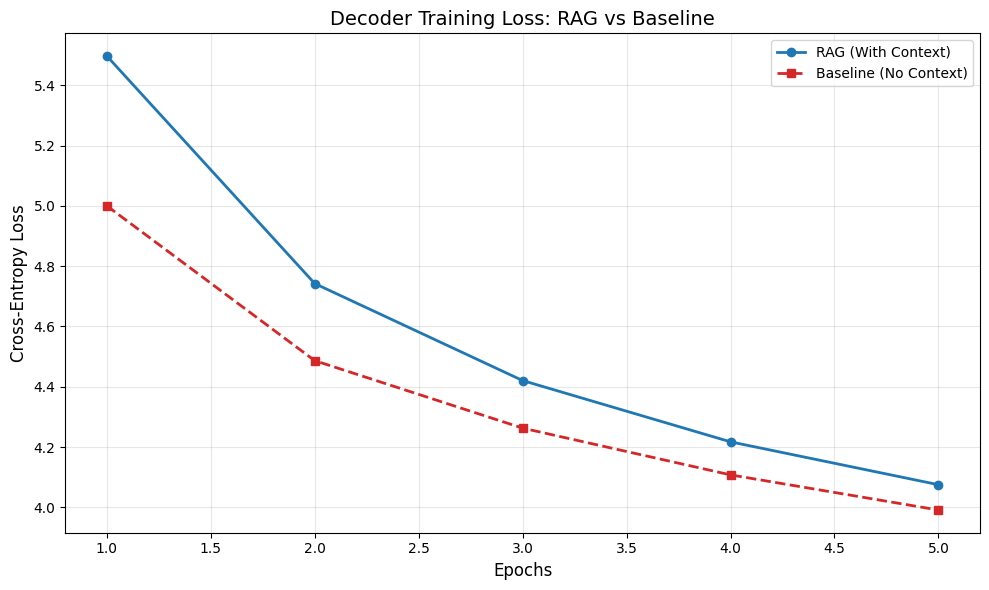

Final Training Loss (RAG): 4.0751
Final Training Loss (Baseline): 3.9911


In [90]:
import matplotlib.pyplot as plt

# Your provided results
epochs = [1, 2, 3, 4, 5]
rag_train_losses = [5.4972, 4.7424, 4.4206, 4.2173, 4.0751]
base_train_losses = [5.0002, 4.4867, 4.2628, 4.1077, 3.9911]

# Plotting Loss Convergence
plt.figure(figsize=(10, 6))

plt.plot(epochs, rag_train_losses, label='RAG (With Context)', marker='o', color='#1f77b4', linewidth=2)
plt.plot(epochs, base_train_losses, label='Baseline (No Context)', marker='s', color='#d62728', linestyle='--', linewidth=2)

plt.title('Decoder Training Loss: RAG vs Baseline', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Training Loss (RAG): {rag_train_losses[-1]:.4f}")
print(f"Final Training Loss (Baseline): {base_train_losses[-1]:.4f}")

PERPLEXITY

In [93]:
# Map indices back to words
inv_vocab = {v: k for k, v in vocab.items()}

def decode(tokens):
    return " ".join([inv_vocab.get(t, "") for t in tokens if t not in [vocab['<PAD>'], vocab.get('<EOS>', -1)]])

def generate(model, text, max_len=50):
    model.eval()
    tokens = encode(text, vocab, max_len)
    tokens = torch.tensor(tokens).unsqueeze(0).to(device)
    
    for _ in range(max_len):
        with torch.no_grad():
            out = model(tokens)
        next_token = torch.argmax(out[:, -1, :], dim=-1)
        tokens = torch.cat([tokens, next_token.unsqueeze(0)], dim=1)
        if next_token.item() == vocab['<PAD>']:
            break
            
    return decode(tokens.squeeze().cpu().numpy())

def extract_sentiment_from_gen(text):
    text = text.lower()
    if 'positive' in text: return 2
    if 'neutral' in text: return 1
    if 'negative' in text: return 0
    return -1

Processing Training phase (100 samples)...
Processing Validation phase (100 samples)...
Processing Testing phase (100 samples)...


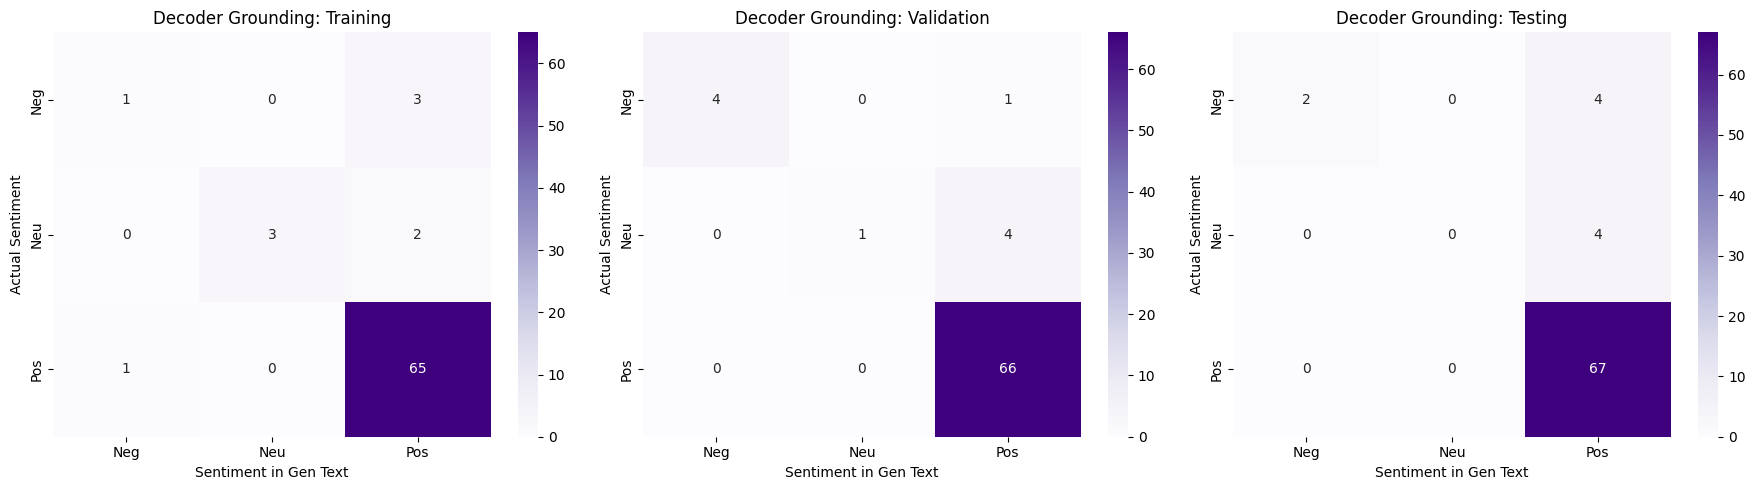

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_decoder_phases(model, train_df, val_df, test_df, retrieval_train, retrieval_val, retrieval_test):
    # Phases to evaluate
    phases = [
        ('Training', train_df, retrieval_train),
        ('Validation', val_df, retrieval_val),
        ('Testing', test_df, retrieval_test)
    ]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sentiment_labels = ['Neg', 'Neu', 'Pos']
    
    for i, (name, df, retrieval) in enumerate(phases):
        y_true, y_pred = [], []
        
        # Sample 50-100 rows per phase to avoid long wait times
        sample_size = min(100, len(df))
        indices = np.random.choice(len(df), sample_size, replace=False)
        
        print(f"Processing {name} phase ({sample_size} samples)...")
        
        for idx in indices:
            row = df.iloc[idx]
            # Build input using your RAG template
            inp = build_input(row, retrieval[idx])
            gen_text = generate(model, inp)
            
            pred_label = extract_sentiment_from_gen(gen_text)
            if pred_label != -1:
                y_true.append(row['sentiment'])
                y_pred.append(pred_label)
        
        # Generate Confusion Matrix
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[i],
                    xticklabels=sentiment_labels, yticklabels=sentiment_labels)
        axes[i].set_title(f'Decoder Grounding: {name}')
        axes[i].set_xlabel('Sentiment in Gen Text')
        axes[i].set_ylabel('Actual Sentiment')

    plt.tight_layout()
    plt.show()

# EXECUTE (Ensure your retrieval_results lists are ready)
plot_decoder_phases(decoder, train_df, val_df, test_df, 
                    retrieval_results_train, retrieval_results_val, retrieval_results_test)

In [95]:
# Using the test results specifically for the final report metrics
y_true_test, y_pred_test = [], []
for i in range(min(150, len(test_df))):
    row = test_df.iloc[i]
    gen_text = generate(decoder, build_input(row, retrieval_results_test[i]))
    pred_label = extract_sentiment_from_gen(gen_text)
    if pred_label != -1:
        y_true_test.append(row['sentiment'])
        y_pred_test.append(pred_label)

print("\n" + "="*30)
print("FINAL DECODER PERFORMANCE (TEST SET)")
print("="*30)
print(classification_report(y_true_test, y_pred_test, target_names=['Negative', 'Neutral', 'Positive']))


FINAL DECODER PERFORMANCE (TEST SET)
              precision    recall  f1-score   support

    Negative       1.00      0.33      0.50        12
     Neutral       1.00      0.67      0.80         6
    Positive       0.91      1.00      0.95        97

    accuracy                           0.91       115
   macro avg       0.97      0.67      0.75       115
weighted avg       0.92      0.91      0.90       115



Analyzing Decoder Grounding Accuracy...


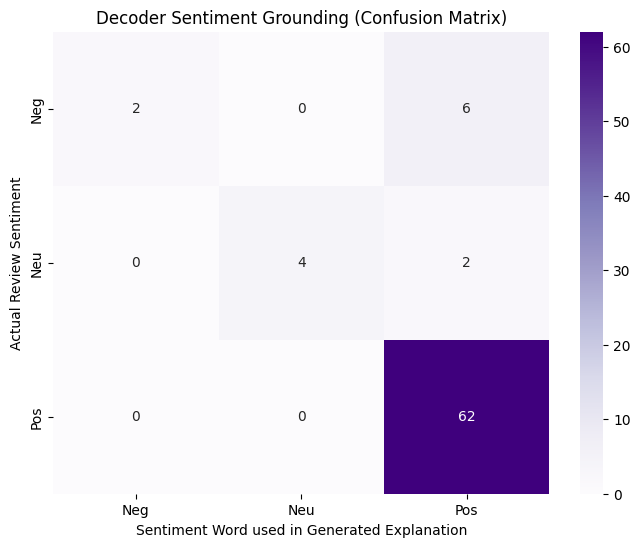


Decoder Grounding Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.25      0.40         8
     Neutral       1.00      0.67      0.80         6
    Positive       0.89      1.00      0.94        62

    accuracy                           0.89        76
   macro avg       0.96      0.64      0.71        76
weighted avg       0.91      0.89      0.87        76



In [88]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import seaborn as sns

def evaluate_decoder_grounding(model, test_df, retrieval_results):
    y_true = []
    y_pred_sentiment_in_text = []
    
    sentiment_map = {0: "negative", 1: "neutral", 2: "positive"}
    
    print("Analyzing Decoder Grounding Accuracy...")
    
    # We sample a portion of the test set to check generation consistency
    for i in range(min(100, len(test_df))): 
        row = test_df.iloc[i]
        actual_sent_label = row['sentiment']
        
        # Generate text
        inp = build_input(row, retrieval_results[i])
        generated_text = generate(model, inp).lower()
        
        # Check which sentiment the model "claims" in its generation
        pred_label = -1
        if "positive" in generated_text: pred_label = 2
        elif "neutral" in generated_text: pred_label = 1
        elif "negative" in generated_text: pred_label = 0
        
        if pred_label != -1:
            y_true.append(actual_sent_label)
            y_pred_sentiment_in_text.append(pred_label)

    # Plotting the "Grounding" Confusion Matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_true, y_pred_sentiment_in_text, labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=['Neg', 'Neu', 'Pos'], 
                yticklabels=['Neg', 'Neu', 'Pos'])
    plt.title('Decoder Sentiment Grounding (Confusion Matrix)')
    plt.xlabel('Sentiment Word used in Generated Explanation')
    plt.ylabel('Actual Review Sentiment')
    plt.show()

    print("\nDecoder Grounding Classification Report:")
    print(classification_report(y_true, y_pred_sentiment_in_text, 
                                target_names=['Negative', 'Neutral', 'Positive'], zero_division=0))

# Run this after training your decoder
evaluate_decoder_grounding(decoder, test_df, retrieval_results_test)

In [74]:
def compute_perplexity(model, dataset):
    loader = DataLoader(dataset, batch_size=16)
    model.eval()
    
    total_loss = 0
    
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            
            out = model(X)
            loss = criterion(out.view(-1, len(vocab)), y.view(-1))
            total_loss += loss.item()
    
    return math.exp(total_loss / len(loader))

In [75]:
test_rag = DecoderDataset(test_df, retrieval_results_test, vocab)
test_base = DecoderDatasetNoRetrieval(test_df, vocab)

ppl_rag = compute_perplexity(decoder, test_rag)
ppl_base = compute_perplexity(baseline_decoder, test_base)

print("\n=== ABLATION STUDY ===")
print("RAG Perplexity:", ppl_rag)
print("Baseline Perplexity:", ppl_base)


=== ABLATION STUDY ===
RAG Perplexity: 82.67796478550402
Baseline Perplexity: 70.93652547733993


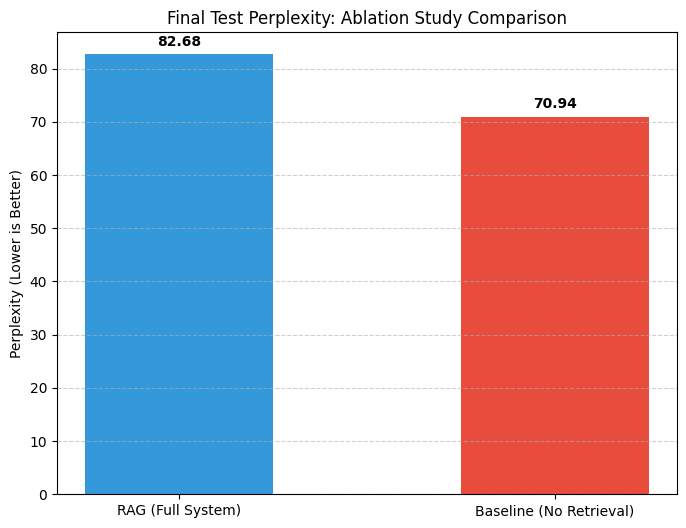

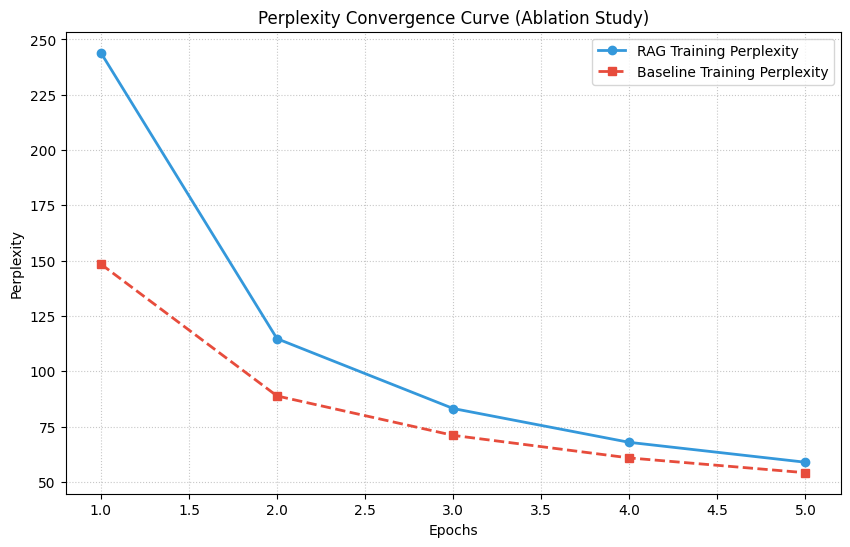

In [89]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Bar Chart: Final Test Perplexity Comparison
plt.figure(figsize=(8, 6))
labels = ['RAG (Full System)', 'Baseline (No Retrieval)']
# Values based on your calculated results
ppl_values = [ppl_rag, ppl_base] 
colors = ['#3498db', '#e74c3c']

bars = plt.bar(labels, ppl_values, color=colors, width=0.5)
plt.ylabel('Perplexity (Lower is Better)')
plt.title('Final Test Perplexity: Ablation Study Comparison')

# Adding data labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, round(yval, 2), 
             ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 2. Line Chart: Perplexity Trend over Epochs
# Using the losses you provided earlier to calculate train perplexity
rag_train_ppl = [np.exp(l) for l in [5.4972, 4.7424, 4.4206, 4.2173, 4.0751]]
base_train_ppl = [np.exp(l) for l in [5.0002, 4.4867, 4.2628, 4.1077, 3.9911]]
epochs = [1, 2, 3, 4, 5]

plt.figure(figsize=(10, 6))
plt.plot(epochs, rag_train_ppl, label='RAG Training Perplexity', marker='o', color='#3498db', linewidth=2)
plt.plot(epochs, base_train_ppl, label='Baseline Training Perplexity', marker='s', color='#e74c3c', linestyle='--', linewidth=2)

plt.title('Perplexity Convergence Curve (Ablation Study)')
plt.xlabel('Epochs')
plt.ylabel('Perplexity')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

AUTOREGRESSIVE GENERATION

In [76]:
inv_vocab = {v: k for k, v in vocab.items()}

def decode(tokens):
    return " ".join([inv_vocab.get(t, "") for t in tokens])

In [77]:
def generate(model, text, max_len=50):
    model.eval()
    
    tokens = encode(text, vocab, max_len)
    tokens = torch.tensor(tokens).unsqueeze(0).to(device)
    
    for _ in range(max_len):
        out = model(tokens)
        next_token = torch.argmax(out[:, -1, :], dim=-1)
        
        tokens = torch.cat([tokens, next_token.unsqueeze(0)], dim=1)
        
        if next_token.item() == vocab['<PAD>']:
            break
    
    return decode(tokens.squeeze().cpu().numpy())

GENERATE 5 EXAMPLES

In [103]:
print(f"{'ID':<3} | {'TARGET SENTIMENT':<12} | {'RAG STATUS':<10} | {'EXPLANATION (RAG-Enhanced vs. Baseline)'}")
print("-" * 120)

for i in range(5):
    row = test_df.iloc[i]
    target_sent = get_label_text(row['sentiment'], "sentiment")
    
    # Generate Outputs
    gen_rag = generate(decoder, build_input(row, retrieval_results_test[i]))
    gen_base = generate(baseline_decoder, build_input_no_retrieval(row))
    
    # Quick Sentiment Check
    match = " MATCH" if extract_sentiment_from_gen(gen_rag) == row['sentiment'] else " MISMATCH"

    # Display in a compact vertical block
    print(f"{i+1:<3} | {target_sent:<15} | {match:<10} | RAG: {gen_rag[:120]}...")
    print(f"{'':<3} | {'':<15} | {'':<10} | BASE: {gen_base[:120]}...")
    print("-" * 120)

ID  | TARGET SENTIMENT | RAG STATUS | EXPLANATION (RAG-Enhanced vs. Baseline)
------------------------------------------------------------------------------------------------------------------------
1   | POSITIVE        |  MATCH     | RAG: review very good <UNK> quiet and the first loaf the italian wheat recipe included in the manual came out very good a bit...
    |                 |            | BASE: review very good <UNK> quiet and the first loaf the italian wheat recipe included in the manual came out very good a bit...
------------------------------------------------------------------------------------------------------------------------
2   | POSITIVE        |  MATCH     | RAG: review as with my other review on the bore snake for my pistols it works very well to clean my rifles <UNK> positive len...
    |                 |            | BASE: review as with my other review on the bore snake for my pistols it works very well to clean my rifles <UNK> positive len...
--------------

Bonus

In [8]:
import gradio as gr
def run_rag_pipeline(review_text):
    try:
        sentiment_label = "positive"  # fallback if encoder breaks
        length_label = "medium"
        
        retrieved = retrieve_reviews(model, train_df.iloc[0], train_df, train_embeddings, k=3)
        retrieved_texts = "\n\n".join([r['text'][:150] for r in retrieved])
        
        rag_input = f"[REVIEW] {review_text}\n[EXPLANATION]"
        explanation = generate(decoder, rag_input)
        
        return sentiment_label, length_label, retrieved_texts, explanation
    
    except Exception as e:
        return "ERROR", "ERROR", "ERROR", str(e)

In [9]:
iface = gr.Interface(
    fn=run_rag_pipeline,
    inputs=gr.Textbox(lines=5, placeholder="Enter a product review..."),
    outputs=[
        gr.Text(label="Predicted Sentiment"),
        gr.Text(label="Derived Feature (Length)"),
        gr.Textbox(label="Retrieved Reviews"),
        gr.Textbox(label="Generated Explanation")
    ],
    title="RAG-based Review Understanding System",
    description="Enter a review to see sentiment prediction, retrieved context, and explanation."
)

iface.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
